/var/folders/5j/jwmnpjk12gd85jt5f8996m740000gn/T/ipykernel_84727/699401512.py:173: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  shift = quad(lambda u: w(r, u, T_i_s, T_i_e) * float(s(u)), T_i_s, T_i_e)[0]
/var/folders/5j/jwmnpjk12gd85jt5f8996m740000gn/T/ipykernel_84727/699401512.py:173: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) 

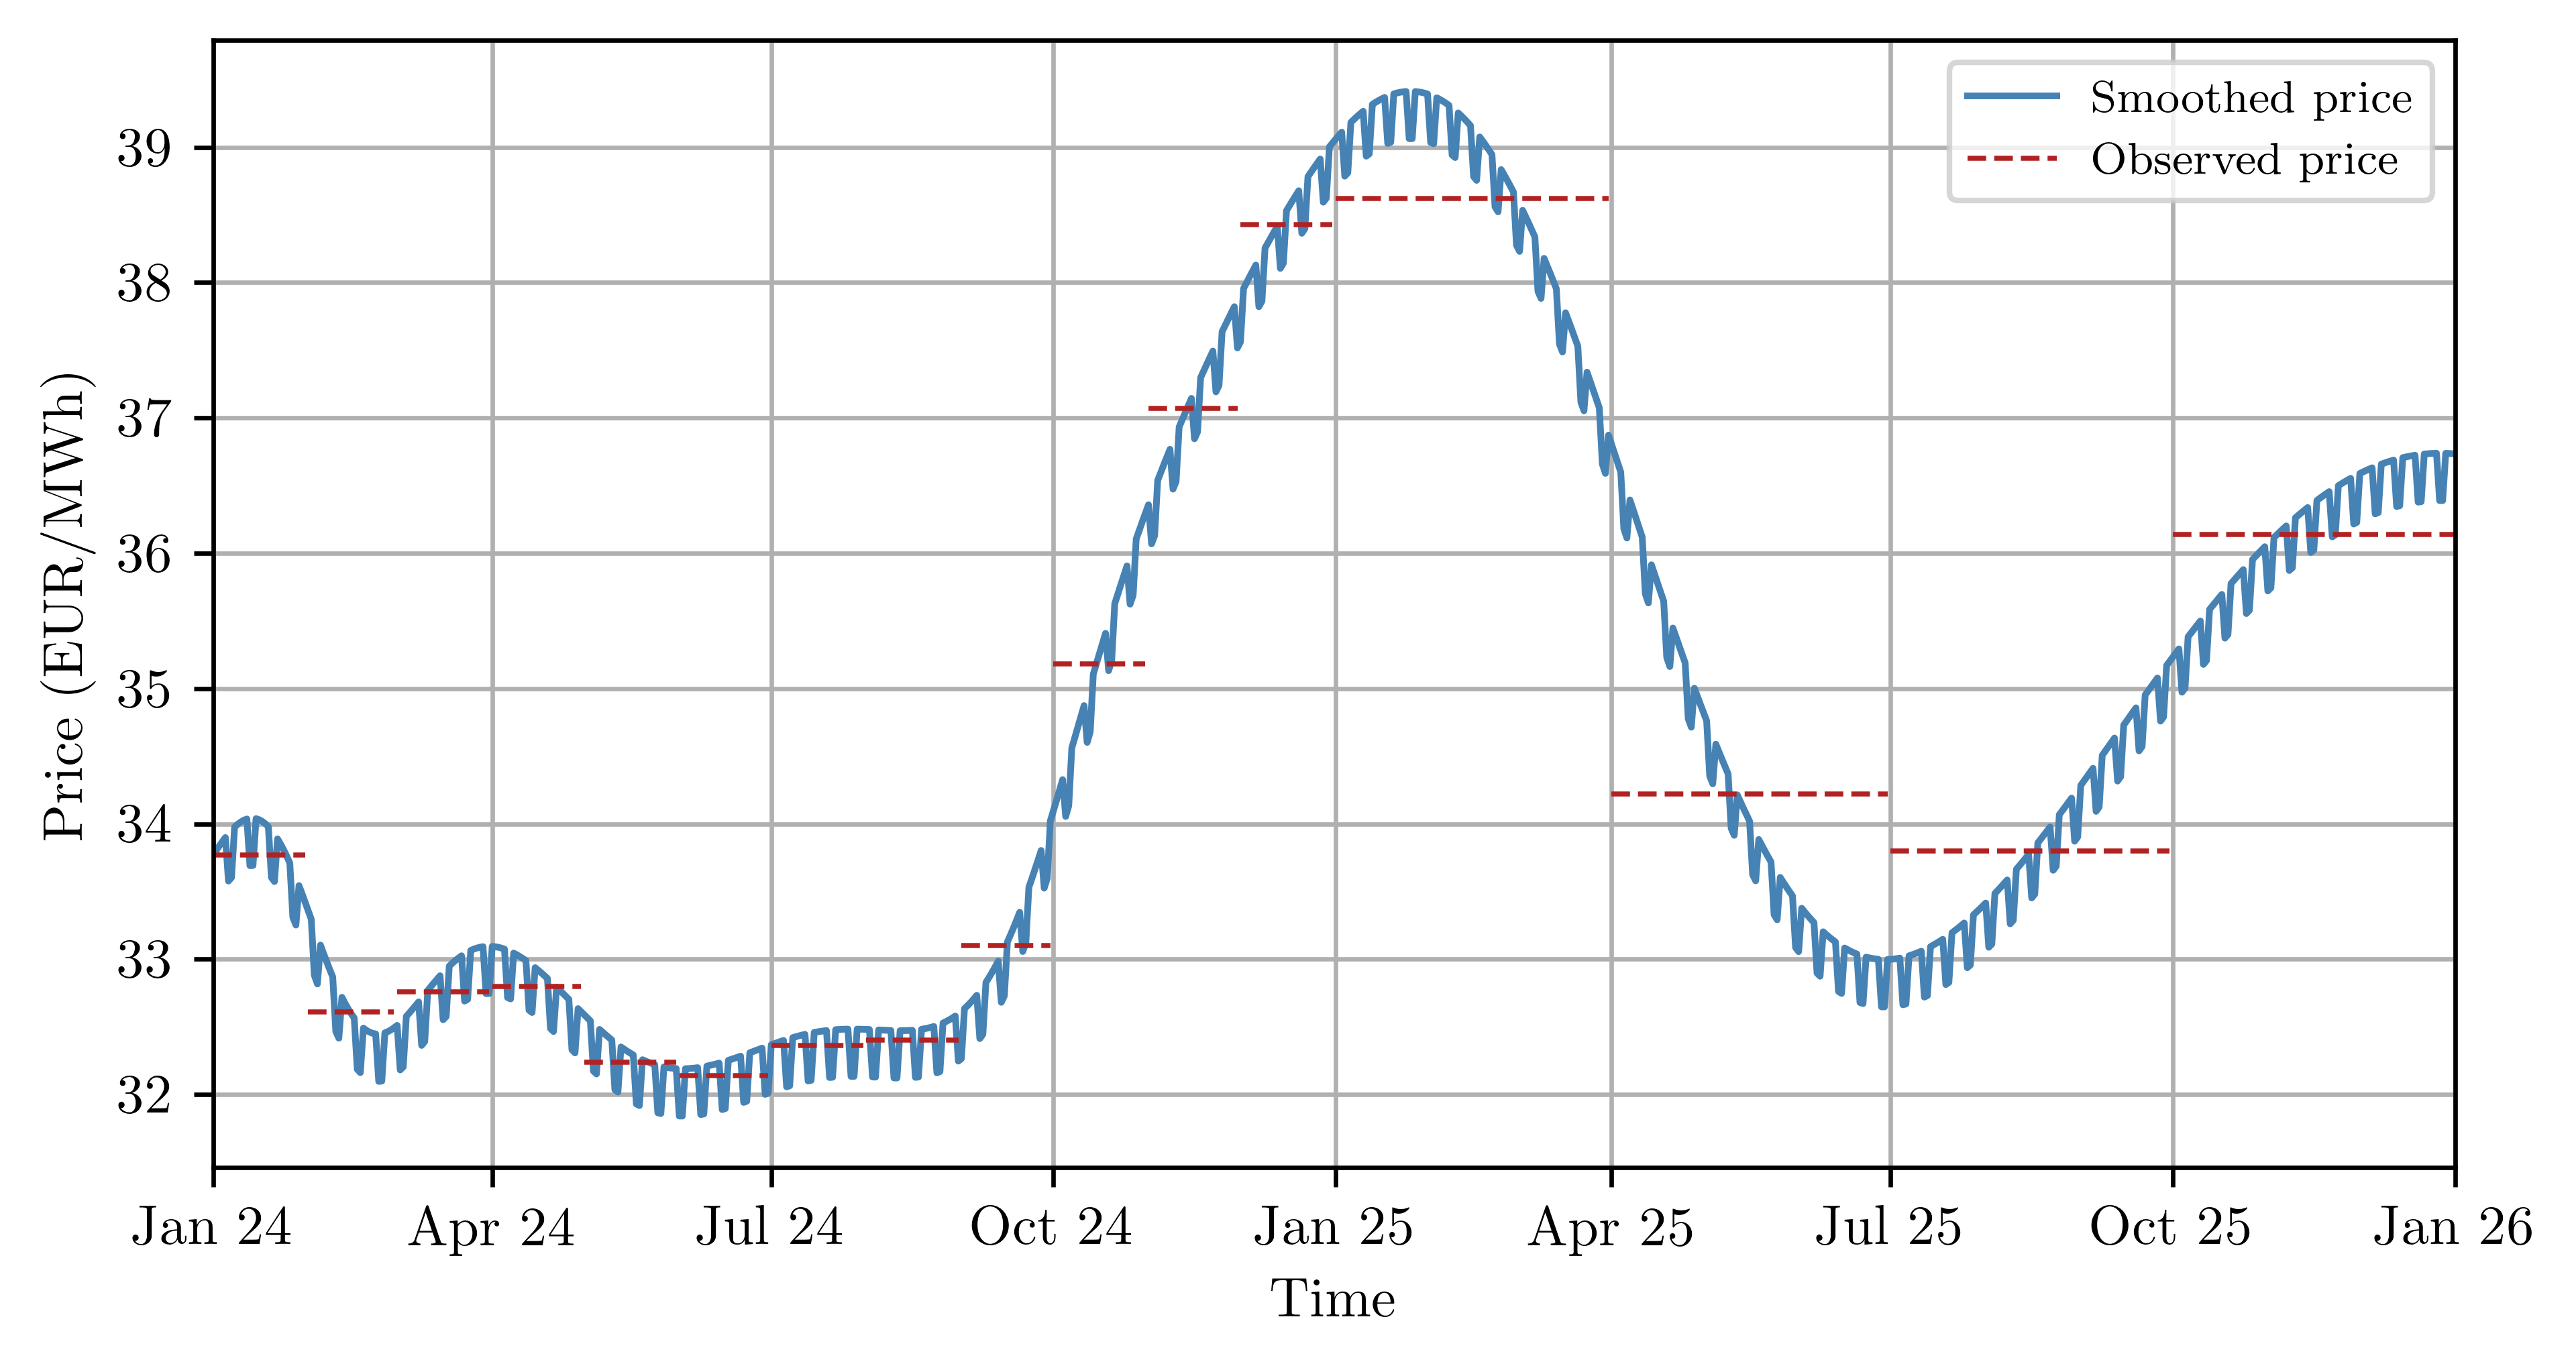

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.linalg import solve
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates


# ----------------------------
# Load data
# ----------------------------
F_C = pd.read_csv("../data/THE_data_original.csv")
seasonal_params = pd.read_csv("../data/seasonal_params.csv")

F_C["delivery_start"] = pd.to_datetime(F_C["delivery_start"], utc=True).dt.tz_convert(None).dt.normalize()
F_C["delivery_end"]   = pd.to_datetime(F_C["delivery_end"], utc=True).dt.tz_convert(None).dt.normalize()
F_C["trading_date"]   = pd.to_datetime(F_C["trading_date"], utc=True).dt.tz_convert(None).dt.normalize()

mask = (
    F_C["contract_type"].isin(["month", "quarter"])
    & (F_C["trading_date"] == pd.Timestamp("2023-12-29"))
    & ~(
        (F_C["contract_type"] == "quarter")
        & (F_C["contract"].str[:4] != "2025")
    )
)
F_C = F_C.loc[mask].copy()


def parse_contract(row: pd.Series) -> pd.Timestamp:
    if row["contract_type"] == "quarter":
        year = int(row["contract"][:4])
        quarter = int(row["contract"][6])
        month = 1 + 3 * (quarter - 1)
        return pd.Timestamp(year=year, month=month, day=1)
    else:
        return pd.to_datetime(f"01 {row['contract']}", format="%d %b %Y")


F_C["contract"] = F_C.apply(parse_contract, axis=1)
F_C = F_C.sort_values("contract").reset_index(drop=True)

date_0 = F_C["delivery_start"].min()

F_C["T_s"] = (F_C["delivery_start"] - date_0).dt.days.astype(float)
F_C["T_e"] = (F_C["delivery_end"] - date_0).dt.days.astype(float)

# ----------------------------
# Knot vector and dimensions
# ----------------------------
t = np.r_[F_C["T_s"].to_numpy(), F_C["T_e"].iloc[-1]] / 365.0
n = len(t) - 1
m = n
Delta = np.diff(t)

r = 0.1

# ----------------------------
# Hessian H
# ----------------------------
H = np.zeros((5 * n, 5 * n), dtype=float)

for j in range(n):
    t_left = t[j]
    t_right = t[j + 1]
    I_j = slice(5 * j, 5 * (j + 1))

    d1 = t_right - t_left
    d2 = t_right**2 - t_left**2
    d3 = t_right**3 - t_left**3
    d4 = t_right**4 - t_left**4
    d5 = t_right**5 - t_left**5

    H_block = np.array([
        [(144 / 5) * d5, 18 * d4, 8 * d3, 0, 0],
        [18 * d4,        12 * d3, 6 * d2, 0, 0],
        [8 * d3,         6 * d2,  4 * d1, 0, 0],
        [0,              0,       0,      0, 0],
        [0,              0,       0,      0, 0],
    ], dtype=float)

    H[I_j, I_j] = H_block

# ----------------------------
# Seasonal component s(t)
# ----------------------------
a0_hat = float(seasonal_params["a0_hat"].iloc[0])
a1_hat = float(seasonal_params["a1_hat"].iloc[0])
a2_hat = float(seasonal_params["a2_hat"].iloc[0])
weekend_spread = -0.35  # EUR/MWh
weekday_shift = -weekend_spread * (2.0 / 7.0)
weekend_shift = weekday_shift + weekend_spread


def week_weekend_component(tau):
    tau = np.asarray(tau, dtype=float)
    day_offsets = np.floor(tau * 365.0 + 1e-12).astype(int)
    calendar_dates = date_0 + pd.to_timedelta(day_offsets, unit="D")
    calendar_index = pd.DatetimeIndex(np.atleast_1d(calendar_dates))
    is_weekend = calendar_index.weekday >= 5
    spread = np.where(is_weekend, weekend_shift, weekday_shift).astype(float)
    return float(spread[0]) if spread.ndim == 1 and spread.size == 1 else spread


def s(tau):
    tau = np.asarray(tau, dtype=float)
    annual_component = np.exp(a1_hat * np.sin(2 * np.pi * tau) + a2_hat * np.cos(2 * np.pi * tau))
    return annual_component + week_weekend_component(tau)
    # return np.zeros_like(tau)  # For testing without seasonality


# ----------------------------
# Weighting function w(r; t)
# ----------------------------
def w(r_: float, u: float, T_s_: float, T_e_: float) -> float:
    denom = (np.exp(-r_ * T_s_) - np.exp(-r_ * T_e_)) / r_
    return np.exp(-r_ * u) / denom


# ----------------------------
# Constraint matrix A and RHS b
# ----------------------------
num_constraints = 3 * (n - 1) + m + 2
A = np.zeros((num_constraints, 5 * n), dtype=float)
b = np.zeros(num_constraints, dtype=float)

row = 0


def phi_0(tau: float) -> np.ndarray:
    return np.array([tau**4, tau**3, tau**2, tau, 1.0], dtype=float)


def phi_1(tau: float) -> np.ndarray:
    return np.array([4 * tau**3, 3 * tau**2, 2 * tau, 1.0, 0.0], dtype=float)


def phi_2(tau: float) -> np.ndarray:
    return np.array([12 * tau**2, 6 * tau, 2.0, 0.0, 0.0], dtype=float)


# C0 / C1 / C2 continuity constraints at interior knots
for j in range(n - 1):
    t_j = t[j + 1]

    I_j = slice(5 * j, 5 * (j + 1))
    I_jplus = slice(5 * (j + 1), 5 * (j + 2))

    A[row, I_j] = -phi_0(t_j)
    A[row, I_jplus] = phi_0(t_j)

    A[row + 1, I_j] = -phi_1(t_j)
    A[row + 1, I_jplus] = phi_1(t_j)

    A[row + 2, I_j] = -phi_2(t_j)
    A[row + 2, I_jplus] = phi_2(t_j)

    row += 3

# Contract consistency constraints
for i in range(m):
    T_i_s = t[i]
    T_i_e = t[i + 1]
    I_i = slice(5 * i, 5 * (i + 1))

    coeffs = np.array([
        quad(lambda u, p=p: w(r, u, T_i_s, T_i_e) * (u**p), T_i_s, T_i_e)[0]
        for p in range(4, -1, -1)
    ])

    shift = quad(lambda u: w(r, u, T_i_s, T_i_e) * float(s(u)), T_i_s, T_i_e)[0]

    A[row, I_i] = coeffs
    b[row] = float(F_C["price"].iloc[i]) - shift

    row += 1

# Boundary condition: epsilon'(t_n; x) = 0
t_n = t[n]
I_n = slice(5 * (n - 1), 5 * n)

A[row, I_n] = phi_1(t_n)
b[row] = 0.0
row += 1

# Initial condition: e_1 = F_0^C
A[row, 4] = 1.0
b[row] = float(F_C["price"].iloc[0]) - float(s(0.0))
row += 1

# ----------------------------
# KKT system
# ----------------------------
KKT = np.block([
    [2 * H, A.T],
    [A, np.zeros((A.shape[0], A.shape[0]))]
])

rhs = np.r_[np.zeros(A.shape[1]), b]

solution = solve(KKT, rhs, assume_a="sym")
x = solution[: 5 * n]

# ----------------------------
# Evaluate epsilon(t; x) on a daily grid
# T_e uses exclusive end-date convention, so exclude the endpoint.
# ----------------------------
t_eval_days = np.arange(0, int(F_C["T_e"].max()))
t_eval = t_eval_days / 365.0

epsilon = np.zeros_like(t_eval, dtype=float)
s_eval = s(t_eval)

for k, tau in enumerate(t_eval):
    # R's findInterval(..., rightmost.closed = TRUE), then clamp to [1, n]
    j = np.searchsorted(t, tau, side="right") - 1
    j = max(0, min(n - 1, j))

    I_j = slice(5 * j, 5 * (j + 1))
    a_j, b_j, c_j, d_j, e_j = x[I_j]

    epsilon[k] = a_j * tau**4 + b_j * tau**3 + c_j * tau**2 + d_j * tau + e_j

forward_curve = epsilon + s_eval

# ----------------------------
# Plotting
# ----------------------------
import matplotlib as mpl
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

dates = date_0 + pd.to_timedelta(t_eval_days, unit="D")

observed_segments = F_C.loc[:, ["delivery_start", "delivery_end", "price"]].copy()
observed_segments.columns = ["x0", "x1", "y"]

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"]
})

fig, ax = plt.subplots(figsize=(6.5, 3.5), dpi=600)

x_start = dates.min().normalize()
x_end = pd.Timestamp("2026-01-01")

# Smoothed forward curve
ax.plot(
    dates,
    forward_curve,
    color="steelblue",
    linewidth=1.2,
    label="Smoothed price"
)

# Observed contract segments
for _, seg in observed_segments.iterrows():
    ax.hlines(
        y=seg["y"],
        xmin=seg["x0"],
        xmax=seg["x1"],
        colors="firebrick",
        linestyles="--",
        linewidth=0.9
    )

# Axis labels
ax.set_xlabel("Time")
ax.set_ylabel("Price (EUR/MWh)")
ax.grid(True)

tick_dates = pd.date_range(start=x_start, end=x_end, freq="3MS")
ax.set_xlim(x_start, x_end)
ax.set_xticks([mdates.date2num(d) for d in tick_dates])
ax.set_xticklabels([d.strftime("%b %y") for d in tick_dates])

# Legend (explicit handles so observed price appears once)
legend_handles = [
    Line2D([0], [0], color="steelblue", linewidth=1.2, label="Smoothed price"),
    Line2D([0], [0], color="firebrick", linestyle="--", linewidth=0.9, label="Observed price")
]

ax.legend(handles=legend_handles, loc="upper right", fontsize=8)

fig.tight_layout()

plt.savefig("../../fig/Plots/forward_curve_corrected.png")
plt.show()

# ----------------------------
# Export forward curve
# ----------------------------
output = pd.DataFrame({
    "date": dates,
    "forward_price": forward_curve
})
output.to_csv("../data/forward_prices_corrected.csv", index=False)